# Eurostat Housing Price Analysis: Bulgaria (Python & R)
This notebook fetches Eurostat House Price Index (HPI) data for Bulgaria, visualizes its evolution, and saves the plots to a dedicated Google Drive folder using both Python and R.

In [1]:
# Step 1: Mount Google Drive and create a project folder
from google.colab import drive
import os

drive.mount('/content/drive')

# Define the target folder path on Google Drive
project_folder = '/content/drive/My Drive/Eurostat_Bulgaria_Housing'
os.makedirs(project_folder, exist_ok=True)
print(f"Project folder is ready at: {project_folder}")

Mounted at /content/drive
Project folder is ready at: /content/drive/My Drive/Eurostat_Bulgaria_Housing


## Python Analysis
We will install `eurostat` and `pandas-datareader` (or query the Eurostat API directly) to fetch the quarterly House Price Index data (dataset code: `prc_hpi_q`).

In [2]:
# Install eurostat python library
!pip install eurostat pandas matplotlib seaborn

In [8]:
import eurostat
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset code for House Price Index (Quarterly)
# prc_hpi_q: House price index, quarterly data
df = eurostat.get_data_df('prc_hpi_q')

# Filter for Bulgaria (geo\TIME_PERIOD = 'BG')
print("Columns:", df.columns[:10])
print("Available units/purchase types:")
display(df[df['geo\\TIME_PERIOD'] == 'BG'][['unit', 'purchase']].drop_duplicates())

Columns: Index(['freq', 'purchase', 'unit', 'geo\TIME_PERIOD', '2005-Q1', '2005-Q2',
       '2005-Q3', '2005-Q4', '2006-Q1', '2006-Q2'],
      dtype='object')
Available units/purchase types:


,unit,purchase
2,I15_Q,DW_EXST
39,I25_Q,DW_EXST
76,RCH_A,DW_EXST
113,RCH_Q,DW_EXST
150,I15_Q,DW_NEW
186,I25_Q,DW_NEW
222,RCH_A,DW_NEW
258,RCH_Q,DW_NEW
294,I15_Q,TOTAL
331,I25_Q,TOTAL


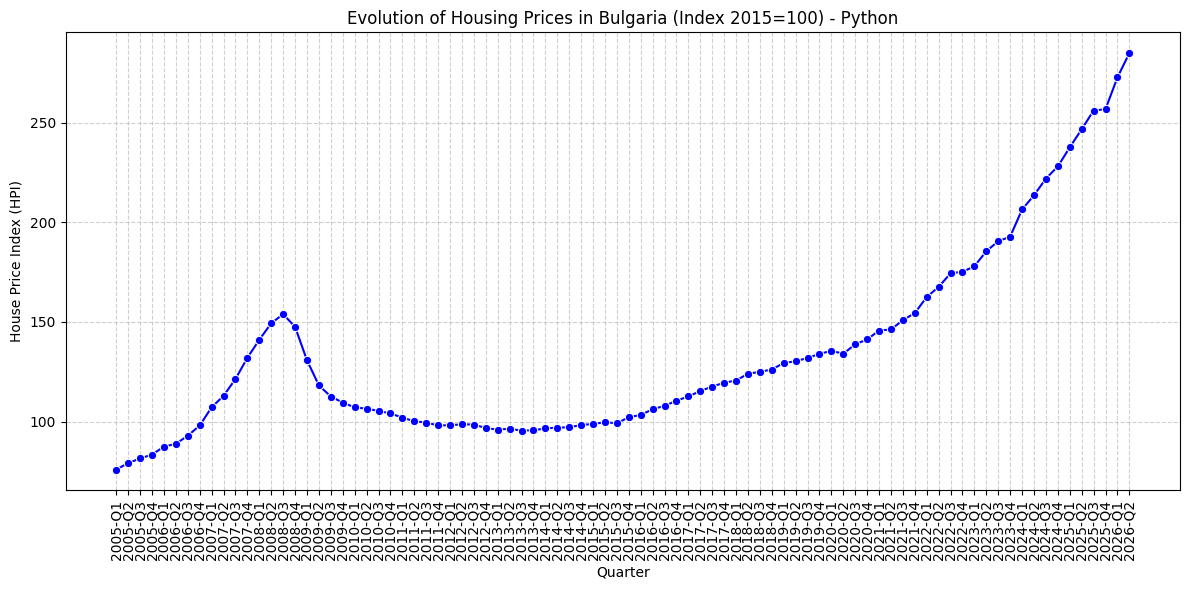

Python chart saved to: /content/drive/My Drive/Eurostat_Bulgaria_Housing/hpi_evolution_bulgaria_python.png


In [12]:
# Filter for Bulgaria, Index (2015=100) or (2010=100), and total purchases
bg_data = df[
    (df['geo\\TIME_PERIOD'] == 'BG') &
    (df['unit'] == 'I15_Q') &
    (df['purchase'] == 'TOTAL')
]

# Reshape the data from wide format to long format for easy plotting
time_cols = [col for col in df.columns if col not in ['unit', 'purchase', 'geo\\TIME_PERIOD', 'freq']]
bg_long = bg_data.melt(id_vars=['unit', 'purchase', 'geo\\TIME_PERIOD'], value_vars=time_cols, var_name='Quarter', value_name='HPI')

# Drop nulls and sort
bg_long = bg_long.dropna().sort_values('Quarter')

# Plot the evolution
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(12, 6))
sns.lineplot(data=bg_long, x='Quarter', y='HPI', marker='o', color='blue')
plt.title('Evolution of Housing Prices in Bulgaria (Index 2015=100) - Python')
plt.xlabel('Quarter')
plt.ylabel('House Price Index (HPI)')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save plot to Google Drive
python_plot_path = os.path.join(project_folder, 'hpi_evolution_bulgaria_python.png')
plt.savefig(python_plot_path, dpi=300)
plt.show()

print(f"Python chart saved to: {python_plot_path}")

## R Analysis
Now we will do the exact same process using R inside this notebook via the `%%R` magic. We'll use the `eurostat` and `ggplot2` R packages.

In [13]:
# Install necessary R packages
!apt-get install r-cran-tidyverse -y
# Activate R magic
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-cran-tidyverse is already the newest version (2.0.0+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [14]:
%%R
# Install eurostat package in R
install.packages("eurostat", repos="http://cran.us.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘proxy’, ‘e1071’, ‘R.oo’, ‘R.methodsS3’, ‘assertthat’, ‘here’, ‘classInt’, ‘countrycode’, ‘ISOweek’, ‘R.utils’, ‘regions’

trying URL 'http://cran.us.r-project.org/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/e1071_1.7-17.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/R.oo_1.27.1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/R.methodsS3_1.8.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/assertthat_0.2.1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/here_1.0.2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/classInt_0.4-11.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/countrycode_1.9.0.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/ISOweek_0.6-2.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/R.utils_2.13.0.tar.gz'
tryin

[1] "Optimized R chart saved to Google Drive!"


Dataset query already saved in cache_list.json...
Reading cache file /tmp/RtmpVFBv9F/eurostat/24991392385b27baa0f357f6bfcd5194.rds
Table  prc_hpi_q  read from cache file:  /tmp/RtmpVFBv9F/eurostat/24991392385b27baa0f357f6bfcd5194.rds


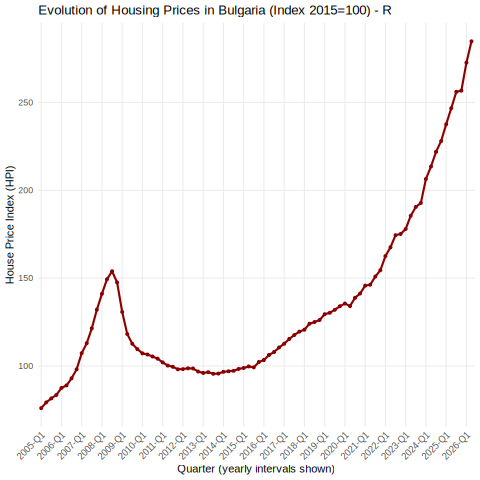

In [18]:
%%R
library(eurostat)
library(ggplot2)
library(dplyr)

# Fetch House Price Index dataset
hpi_df <- get_eurostat("prc_hpi_q", time_format = "raw")

# Filter for Bulgaria, Index (2015=100), Total purchases
bg_hpi <- hpi_df %>%
  filter(geo == "BG", unit == "I15_Q", purchase == "TOTAL")

if ("TIME_PERIOD" %in% colnames(bg_hpi)) {
  bg_hpi <- bg_hpi %>%
    rename(time_col = TIME_PERIOD) %>%
    arrange(time_col)
} else if ("time" %in% colnames(bg_hpi)) {
  bg_hpi <- bg_hpi %>%
    rename(time_col = time) %>%
    arrange(time_col)
}

# Create a subset of breaks to show on the x-axis to prevent overlapping
# We will select every 4th quarter (once per year) for the labels
unique_quarters <- unique(bg_hpi$time_col)
selected_breaks <- unique_quarters[seq(1, length(unique_quarters), by = 4)]

# Plot the HPI evolution with optimized x-axis labels
p <- ggplot(bg_hpi, aes(x = time_col, y = values, group = 1)) +
  geom_line(color = "darkred", size = 1) +
  geom_point(color = "darkred", size = 1.2) +
  scale_x_discrete(breaks = selected_breaks) +
  theme_minimal() +
  labs(
    title = "Evolution of Housing Prices in Bulgaria (Index 2015=100) - R",
    x = "Quarter (yearly intervals shown)",
    y = "House Price Index (HPI)"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 9),
    panel.grid.minor = element_blank()
  )

print(p)

# Save the plot directly to the Google Drive folder
ggsave("/content/drive/My Drive/Eurostat_Bulgaria_Housing/hpi_evolution_bulgaria_r.png", plot = p, width = 10, height = 5, dpi = 300)
print("Optimized R chart saved to Google Drive!")

In [17]:
import shutil
import os

# Source notebook path
source_notebook = '/content/drive/My Drive/Colab Notebooks/eurostat_data.ipynb'

# Destination folder path
target_folder = '/content/drive/My Drive/Eurostat_Bulgaria_Housing'
target_notebook = os.path.join(target_folder, 'eurostat_data.ipynb')

# Ensure the target folder exists
os.makedirs(target_folder, exist_ok=True)

# Move the notebook file
if os.path.exists(source_notebook):
    shutil.move(source_notebook, target_notebook)
    print(f"Successfully moved the notebook to: {target_notebook}")
else:
    print(f"Could not find notebook at {source_notebook}. Please check if the name matches.")

Successfully moved the notebook to: /content/drive/My Drive/Eurostat_Bulgaria_Housing/eurostat_data.ipynb


In [28]:
# Replace these variables with your own details
REPO_URL = "github.com/StoyanovKS/EUROstat_housing_data_BG.git"
COMMIT_EMAIL = "krasen.stoyanov92@gmail.com"
COMMIT_NAME = "StoyanovKS"

import os
import shutil
from google.colab import userdata

try:
    token = userdata.get('GITHUB_TOKEN')

    # 1. Setup a clean local workspace directory away from /content root and drive/
    workspace = "/content/git_workspace"
    if os.path.exists(workspace):
        shutil.rmtree(workspace)
    os.makedirs(workspace)
    os.chdir(workspace)

    # 2. Copy only project files from Drive to workspace
    drive_folder = "/content/drive/My Drive/Eurostat_Bulgaria_Housing/"
    if os.path.exists(drive_folder):
        for file in os.listdir(drive_folder):
            full_path = os.path.join(drive_folder, file)
            if os.path.isfile(full_path):
                shutil.copy(full_path, workspace)
    else:
        # Fallback to current runtime root files if drive folder is missing
        shutil.copy("/content/eurostat_data.ipynb", workspace) if os.path.exists("/content/eurostat_data.ipynb") else None
        shutil.copy("/content/hpi_evolution_bulgaria_python.png", workspace) if os.path.exists("/content/hpi_evolution_bulgaria_python.png") else None
        shutil.copy("/content/hpi_evolution_bulgaria_r.png", workspace) if os.path.exists("/content/hpi_evolution_bulgaria_r.png") else None

    # Create a README if it doesn't exist
    if not os.path.exists("README.md"):
        with open("README.md", "w") as f:
            f.write("# Eurostat Bulgaria Housing Price Project\n\nContains pipeline code in Python & R to visualize and archive HPI quarterly records.\n")

    # 3. Initialize Git in the clean workspace folder
    !git init
    !git config --global user.email "{COMMIT_EMAIL}"
    !git config --global user.name "{COMMIT_NAME}"

    # Add, commit, and prepare branch
    !git add .
    !git commit -m "first commit with notebook and charts"
    !git branch -M main

    # 4. Authenticate and push to repository
    auth_url = f"https://{token}@{REPO_URL}"
    !git remote rm origin 2>/dev/null || true
    !git remote add origin {auth_url}
    !git push -u origin main --force

    print("\nSuccessfully pushed your notebook and charts to GitHub!")
except Exception as e:
    print(f"Setup failed. Did you configure correct scopes (repo write access) for your GITHUB_TOKEN? Error: {e}")
finally:
    # Return to root runtime path
    os.chdir("/content")

Copying files from Google Drive to local workspace...
-> Staged: eurostat_data.ipynb
-> Staged: hpi_evolution_bulgaria_python.png
-> Staged: hpi_evolution_bulgaria_r.png
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/git_workspace/.git/
[master (root-commit) 64a5ec6] first commit with notebook and charts
 4 files changed, 4 insertions(+)
 create mode 100644 README.md
 create mode 100644 eurostat_data.ipynb
 create mode 100644 hpi_evolution_bulgaria_python.png
 create mode 100644 hpi_evolution_bulgaria_r.png
Push